<a href="https://colab.research.google.com/github/Najla-abdullah6/-/blob/main/prodectN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== أول 5 أعمدة من البيانات ===
  تاريخ_الشراء       المنتج       الفئة  سعر_الوحدة  الكمية  إجمالي_المبيعات
0   2026-01-01         شاشة   إكسسوارات         250       2              500
1   2026-01-02  لوحة مفاتيح  إلكترونيات        3500       3            10500
2   2026-01-03       سماعات  إلكترونيات         150       5              750
3   2026-01-04  لوحة مفاتيح   إكسسوارات        3500       1             3500
4   2026-01-05  لوحة مفاتيح   إكسسوارات         250       4             1000 

=== الملخص الإحصائي للمبيعات ===
        سعر_الوحدة      الكمية  إجمالي_المبيعات
count   100.000000  100.000000       100.000000
mean   1681.500000    2.910000      4507.000000
std    1320.079103    1.443166      4357.583776
min     150.000000    1.000000       150.000000
25%     250.000000    2.000000      1000.000000
50%    1200.000000    3.000000      3500.000000
75%    3500.000000    4.000000      6700.000000
max    3500.000000    5.000000     17500.000000 

إجمالي الإيرادات الكلية: 450,700 ريال

/tmp/ipykernel_2012/1822532710.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=sales_by_product.index, y=sales_by_product.values, palette='Blues_r')


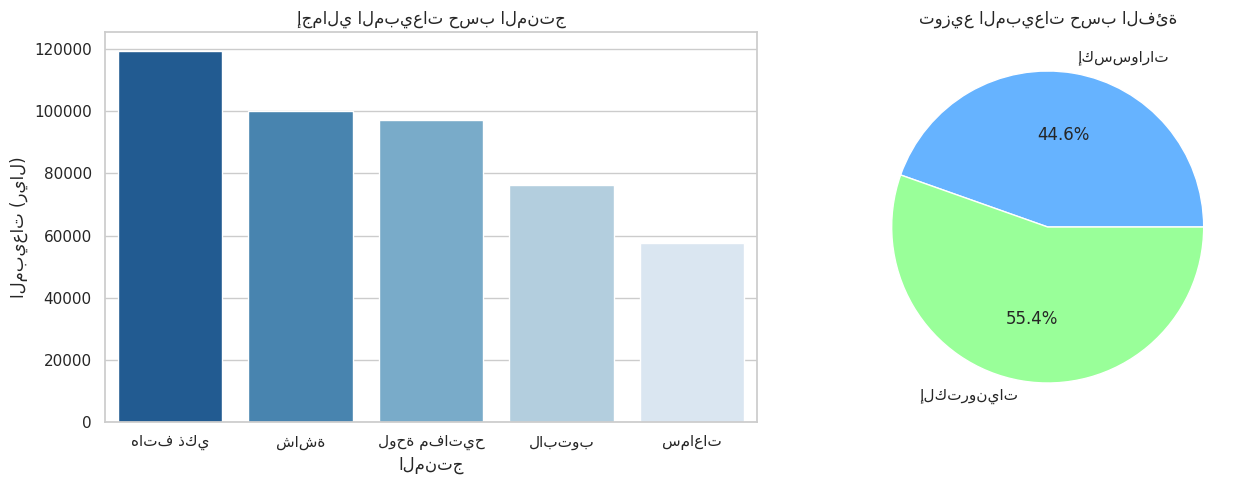

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ضبط مظهر الرسم البياني
sns.set_theme(style="whitegrid")

# 1. إنشاء مجموعة بيانات افتراضية للمبيعات
np.random.seed(42)
n_rows = 100

data = {
    'تاريخ_الشراء': pd.date_range(start='2026-01-01', periods=n_rows, freq='D'),
    'المنتج': np.random.choice(['لابتوب', 'هاتف ذكي', 'سماعات', 'شاشة', 'لوحة مفاتيح'], size=n_rows),
    'الفئة': np.random.choice(['إلكترونيات', 'إكسسوارات'], size=n_rows),
    'سعر_الوحدة': np.random.choice([3500, 2200, 250, 1200, 150], size=n_rows),
    'الكمية': np.random.randint(1, 6, size=n_rows)
}

df = pd.DataFrame(data)

# 2. معالجة وحساب البيانات
# إضافة عمود إجمالي المبيعات (السعر × الكمية)
df['إجمالي_المبيعات'] = df['سعر_الوحدة'] * df['الكمية']

# 3. استكشاف البيانات الإحصائية
print("=== أول 5 أعمدة من البيانات ===")
print(df.head(), "\n")

print("=== الملخص الإحصائي للمبيعات ===")
print(df[['سعر_الوحدة', 'الكمية', 'إجمالي_المبيعات']].describe(), "\n")

# 4. تحليل النتائج الرئيسية
total_revenue = df['إجمالي_المبيعات'].sum()
sales_by_product = df.groupby('المنتج')['إجمالي_المبيعات'].sum().sort_values(ascending=False)
sales_by_category = df.groupby('الفئة')['إجمالي_المبيعات'].sum()

print(f"إجمالي الإيرادات الكلية: {total_revenue:,} ريال\n")
print("=== الإيرادات حسب المنتج ===")
print(sales_by_product, "\n")

# 5. التمثيل البياني (Data Visualization)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# الرسم الأول: أداء المبيعات حسب المنتج
sns.barplot(ax=axes[0], x=sales_by_product.index, y=sales_by_product.values, palette='Blues_r')
axes[0].set_title('إجمالي المبيعات حسب المنتج')
axes[0].set_xlabel('المنتج')
axes[0].set_ylabel('المبيعات (ريال)')

# الرسم الثاني: نسبة المبيعات حسب الفئة
axes[1].pie(sales_by_category, labels=sales_by_category.index, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
axes[1].set_title('توزيع المبيعات حسب الفئة')

plt.tight_layout()
plt.show()